# 2. Statistisk Analys
Deskriptiv statistik, fördelningar och normalitetstest för WHR26-variablerna.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_excel("../data/WHR26_Data_Figure_2.1.xlsx")

In [38]:
# Ta bort rader där "Country name" är "World"
kolumner = [
    "Year", "Country name",
    "Life evaluation (3-year average)",
    "Explained by: Log GDP per capita",
    "Explained by: Social support",
    "Explained by: Healthy life expectancy",
    "Explained by: Freedom to make life choices",
    "Explained by: Generosity",
    "Explained by: Perceptions of corruption"
]

df = df_raw[df_raw["Year"].between(2019, 2025)][kolumner].copy()
df = df.dropna()

länder_båda = set(df[df["Year"] == 2019]["Country name"]) & set(df[df["Year"] == 2025]["Country name"])
df = df[df["Country name"].isin(länder_båda)].copy()

# Skapa en ny kolumn "Year_diff" som är skillnaden mellan 2025 och 2019
faktorer = [
    "Explained by: Log GDP per capita",
    "Explained by: Social support",
    "Explained by: Healthy life expectancy",
    "Explained by: Freedom to make life choices",
    "Explained by: Generosity",
    "Explained by: Perceptions of corruption"
]

print(f"Rader: {df.shape[0]}, Länder: {df['Country name'].nunique()}")

Rader: 975, Länder: 141


In [39]:
# Beräkna förändringen i "Life evaluation (3-year average)" mellan 2019 och 2025 för varje land
# Skapa två DataFrames, en för 2019 och en för 2025, och slå ihop dem på "Country name"
df_2019 = df[df["Year"] == 2019].set_index("Country name")[["Life evaluation (3-year average)"]]
df_2025 = df[df["Year"] == 2025].set_index("Country name")[["Life evaluation (3-year average)"]]

df_förändring = df_2019.join(df_2025, lsuffix="_2019", rsuffix="_2025")
df_förändring["delta"] = (
    df_förändring["Life evaluation (3-year average)_2025"]
    - df_förändring["Life evaluation (3-year average)_2019"]
)
df_förändring = df_förändring.sort_values("delta", ascending=False)

print(df_förändring.head(10))   # topp 10 vinnare
print(df_förändring.tail(10))   # topp 10 förlorare

              Life evaluation (3-year average)_2019  \
Country name                                          
Viet Nam                                     5.3535   
India                                        3.5733   
China                                        5.1239   
Serbia                                       5.7782   
Armenia                                      4.6768   
Georgia                                      4.6726   
Albania                                      4.8827   
Lesotho                                      3.6528   
Mozambique                                   4.6236   
Algeria                                      5.0051   

              Life evaluation (3-year average)_2025   delta  
Country name                                                 
Viet Nam                                      6.428  1.0745  
India                                         4.536  0.9627  
China                                         6.074  0.9501  
Serbia                       

In [40]:
# Visa topp 10 vinnare och förlorare
# Vi kan runda av "delta" till 3 decimaler för bättre läsbarhet
topp10_vinnare   = df_förändring.head(10)
topp10_förlorare = df_förändring.tail(10)

print("=== VINNARE ===")
print(topp10_vinnare[["delta"]].round(3))

print("\n=== FÖRLORARE ===")
print(topp10_förlorare[["delta"]].round(3))

=== VINNARE ===
              delta
Country name       
Viet Nam      1.075
India         0.963
China         0.950
Serbia        0.913
Armenia       0.907
Georgia       0.844
Albania       0.779
Lesotho       0.722
Mozambique    0.712
Algeria       0.709

=== FÖRLORARE ===
              delta
Country name       
Bangladesh   -0.514
Switzerland  -0.542
DR Congo     -0.550
Ghana        -0.594
Sierra Leone -0.675
Congo        -0.738
Benin        -0.823
Pakistan     -0.825
Lebanon      -1.049
Afghanistan  -1.121


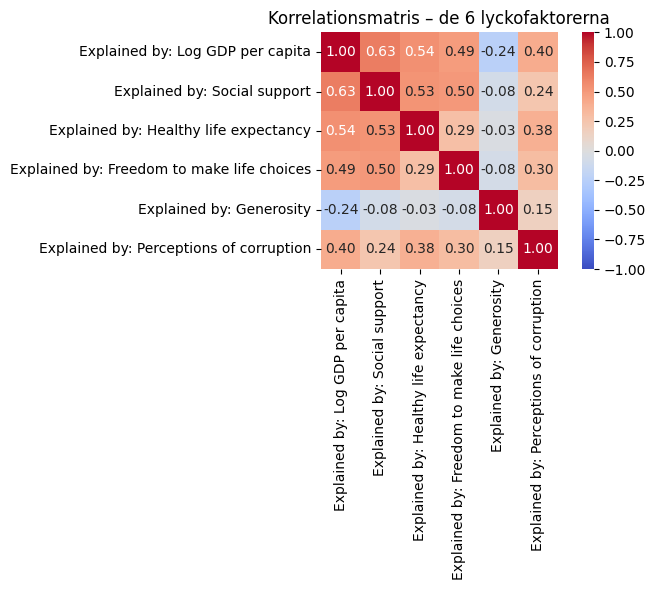

In [41]:
# Skapa en korrelationsmatris för de 6 lyckofaktorerna
# Visar hur starkt de 6 faktorerna hänger ihop med varandra. 
# Celler nära +1 (röd) = rör sig tillsammans, nära 0 (vit) = oberoende, nära −1 (blå) = omvänt samband.
korr = df[faktorer].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    korr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True
)
# Vi kan lägga till en titel och justera layouten för att göra det snyggare
plt.title("Korrelationsmatris – de 6 lyckofaktorerna")
plt.tight_layout()
plt.show()

In [42]:
# Visar genomsnittsvärdet på varje faktor för de 10 vinnarna respektive de 10 förlorarna (vid 2019 — startläget). 
# Raden med störst skillnad är den faktor som troligtvis skiljer dem åt mest.
df_2019_full = df[df["Year"] == 2019].set_index("Country name")

# Beräkna genomsnittet av varje faktor för topp 10 vinnare och topp 10 förlorare
vinnare_snitt = df_2019_full.loc[topp10_vinnare.index, faktorer].mean()
förlorare_snitt = df_2019_full.loc[topp10_förlorare.index, faktorer].mean()

# Skapa en DataFrame för att jämföra vinnare och förlorare
jämförelse = pd.DataFrame({
    "Vinnare (snitt)": vinnare_snitt,
    "Förlorare (snitt)": förlorare_snitt,
    "Skillnad": vinnare_snitt - förlorare_snitt
}).round(3)

print(jämförelse.sort_values("Skillnad", ascending=False))

                                            Vinnare (snitt)  \
Explained by: Log GDP per capita                      0.757   
Explained by: Social support                          1.014   
Explained by: Healthy life expectancy                 0.654   
Explained by: Freedom to make life choices            0.461   
Explained by: Perceptions of corruption               0.102   
Explained by: Generosity                              0.137   

                                            Förlorare (snitt)  Skillnad  
Explained by: Log GDP per capita                        0.563     0.193  
Explained by: Social support                            0.842     0.172  
Explained by: Healthy life expectancy                   0.496     0.158  
Explained by: Freedom to make life choices              0.384     0.077  
Explained by: Perceptions of corruption                 0.116    -0.014  
Explained by: Generosity                                0.206    -0.068  
